## Decision trees and random forests for obesity habits classification 

This paper contains data for the estimation of obesity levels in people from the countries of Mexico,
Peru and Colombia, with ages between 14 and 61 and diverse eating habits and physical condition as
mentioned by [1].

Data was collected using a web platform with a survey (see Table 1) where anon-
ymous users answered each question, then the information was processed obtaining 17 attributes and
2111 records, after a balancing process described in Figs. 1 and 2.

### The attributes related with eating habits are: 

- Frequent consumption of high caloric food (FAVC),
- Frequency of consumption of vegetables (FCVC), 
- Number of main meals (NCP), 
- Consumption of food between meals (CAEC),
- Consumption of water daily (CH20),
- Consumption of alcohol (CALC). 

### The attributes related with the physical condition are: 

- Calories consumption monitoring (SCC), 
- Physical activity frequency (FAF), 
- Time using technology devices (TUE),
- Transportation used (MTRANS)

### other variables obtained were: 
- Gender, 
- Age,
- Height 
- Weight.

Finally, all data was labeled and the class variable NObesity was created with the
values of: 
- Insuf cient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I,
Obesity Type II and Obesity Type III, based on Equation (1) and information from WHO and Mexican
Normativity.

 The data contains numerical data and continous data, so it can be used for analysis based
on algorithms of classi cation, prediction, segmentation and association. Data is available in CSV
format and ARFF format to be used with the Weka tool.

In [380]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import scipy

In [381]:
df = pd.read_csv("data/ObesityDataSet_raw_and_data_sinthetic.csv")

In [382]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [383]:
df.head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [384]:
n, p =df.shape
n, p

(2111, 17)

## Train / test separation

In [385]:
def split_train_test(data : pd.DataFrame, test_ratio, y):
    shuffle = np.random.permutation(n)
    separator = int(test_ratio*n)
    tr_indices = shuffle[:separator]
    te_indices = shuffle[separator:]

    return data.iloc[tr_indices], data.iloc[te_indices], y[tr_indices], y[te_indices]

In [386]:
tr_data, te_data, y_tr, y_te = split_train_test(df, 0.8, df["NObeyesdad"])

In [387]:
tr_data.head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
4,Male,22.000000,1.780000,89.800000,no,no,2.000000,1.000000,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
130,Female,20.000000,1.580000,53.000000,yes,yes,2.000000,4.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Public_Transportation,Normal_Weight
1506,Male,21.353237,1.709731,95.032177,yes,yes,2.000000,2.973476,Sometimes,no,2.000000,no,0.000000,1.331527,no,Public_Transportation,Obesity_Type_I
1607,Male,37.084742,1.750000,118.073810,yes,yes,2.133964,3.000000,Sometimes,no,2.008361,no,0.202029,0.200516,Sometimes,Automobile,Obesity_Type_II
1111,Male,18.011718,1.680991,79.752916,yes,yes,2.413156,2.521546,Sometimes,no,1.985312,no,0.007050,0.965464,Sometimes,Public_Transportation,Overweight_Level_II
1463,Male,20.993067,1.782269,104.970030,yes,yes,2.000000,3.000000,Sometimes,no,1.234943,no,0.008368,0.000000,Sometimes,Public_Transportation,Obesity_Type_I
2110,Female,23.664709,1.738836,133.472641,yes,yes,3.000000,3.000000,Sometimes,no,2.863513,no,1.026452,0.714137,Sometimes,Public_Transportation,Obesity_Type_III
70,Female,23.000000,1.650000,80.000000,yes,yes,2.000000,3.000000,Always,no,2.000000,no,0.000000,2.000000,no,Public_Transportation,Overweight_Level_II
1567,Male,30.520854,1.784049,120.644178,yes,yes,2.499108,3.000000,Sometimes,no,2.040952,no,0.838739,0.489854,Sometimes,Automobile,Obesity_Type_II
772,Male,20.000000,1.831357,89.652557,yes,yes,2.555401,3.292386,Sometimes,no,3.000000,no,2.000000,0.315918,Sometimes,Public_Transportation,Overweight_Level_I


## Categorical vs numerical variables

In [388]:
numerical_variables = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]
categorical_variables = ["Gender", "family_history_with_overweight", "CAEC", "SMOKE", "SCC", "CALC", "MTRANS"]

In [389]:
from sklearn.preprocessing import OrdinalEncoder


In [390]:
df[categorical_variables]

,Gender,family_history_with_overweight,CAEC,SMOKE,SCC,CALC,MTRANS
0,Female,yes,Sometimes,no,no,no,Public_Transportation
1,Female,yes,Sometimes,yes,yes,Sometimes,Public_Transportation
2,Male,yes,Sometimes,no,no,Frequently,Public_Transportation
3,Male,no,Sometimes,no,no,Frequently,Walking
4,Male,no,Sometimes,no,no,Sometimes,Public_Transportation
...,...,...,...,...,...,...,...
2106,Female,yes,Sometimes,no,no,Sometimes,Public_Transportation
2107,Female,yes,Sometimes,no,no,Sometimes,Public_Transportation
2108,Female,yes,Sometimes,no,no,Sometimes,Public_Transportation
2109,Female,yes,Sometimes,no,no,Sometimes,Public_Transportation


In [391]:
labels = list(df["NObeyesdad"].unique())

## Pipeline computation

In [392]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [393]:
num_pipeline = Pipeline([("imputer", SimpleImputer(strategy='median')),
                        ("std_scaler", StandardScaler())])

In [394]:
full_pipeline = ColumnTransformer([("num", num_pipeline, numerical_variables),
                                   ("cat", OrdinalEncoder(), categorical_variables)])

tr_data = full_pipeline.fit_transform(tr_data)
te_data = full_pipeline.fit_transform(te_data)

## Training a first model

In [395]:
y = df[["NObeyesdad"]]

In [396]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=10)
dt.fit(tr_data, y_tr)

,criterion,'entropy'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [397]:
y_pred = dt.predict(te_data)

In [398]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [399]:
cm = confusion_matrix(y_te, y_pred, labels= labels)

In [400]:
display = ConfusionMatrixDisplay(cm, display_labels=labels)

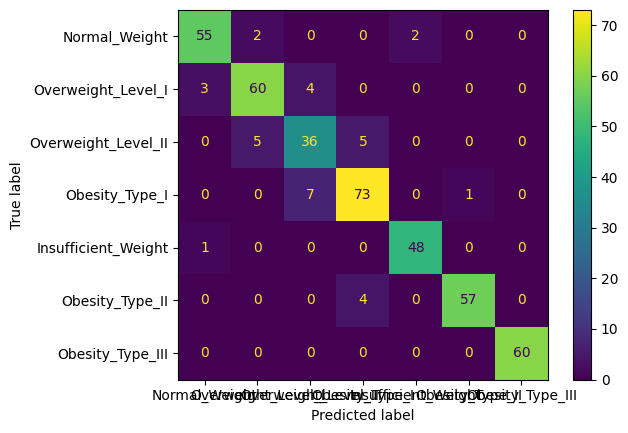

In [401]:
display.plot()